In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
df = pd.read_csv('../PJM(AEP)_energy_dataset.csv')

In [91]:
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [92]:
df.tail()

,Datetime,PJME_MW
145361,2018-01-01 20:00:00,44284.0
145362,2018-01-01 21:00:00,43751.0
145363,2018-01-01 22:00:00,42402.0
145364,2018-01-01 23:00:00,40164.0
145365,2018-01-02 00:00:00,38608.0


In [93]:
df.shape

(145366, 2)

In [94]:
print(df.dtypes)

 Datetime    str
PJME_MW      str
dtype: object


In [95]:
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_percent.round(2)
})

print(missing_summary)
print(f"\n Total missing values: {df.isnull().sum().sum()}")
print("✅ No missing values found! Dataset is complete.")

           Missing Count  Missing Percentage (%)
 Datetime              0                     0.0
PJME_MW                0                     0.0

 Total missing values: 0
✅ No missing values found! Dataset is complete.


In [96]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [97]:
df.describe()

,Datetime,PJME_MW
count,145366,145366
unique,145362,28442
top,2014-11-02 02:00:00,30051.0
freq,2,24


In [98]:
df['PJME_MW'].count


<bound method Series.count of 0         26498.0
1         25147.0
2         24574.0
3         24393.0
4         24860.0
           ...   
145361    44284.0
145362    43751.0
145363    42402.0
145364    40164.0
145365    38608.0
Name: PJME_MW, Length: 145366, dtype: str>

In [99]:
target_col = 'PJME_MW'

# Convert to numeric (in case data has commas or is stored as string)
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

Q1 = df[target_col].quantile(0.25)
Q2 = df[target_col].quantile(0.50)  # Median
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1

print("📊 Quartile Analysis:")
print(f"Q1 (25th percentile): {Q1:,.2f} MW")
print(f"Q2 (Median):          {Q2:,.2f} MW")
print(f"Q3 (75th percentile): {Q3:,.2f} MW")
print(f"IQR (Q3 - Q1):        {IQR:,.2f} MW")

📊 Quartile Analysis:
Q1 (25th percentile): 27,573.00 MW
Q2 (Median):          31,421.00 MW
Q3 (75th percentile): 35,650.00 MW
IQR (Q3 - Q1):        8,077.00 MW


<Axes: ylabel='PJME_MW'>

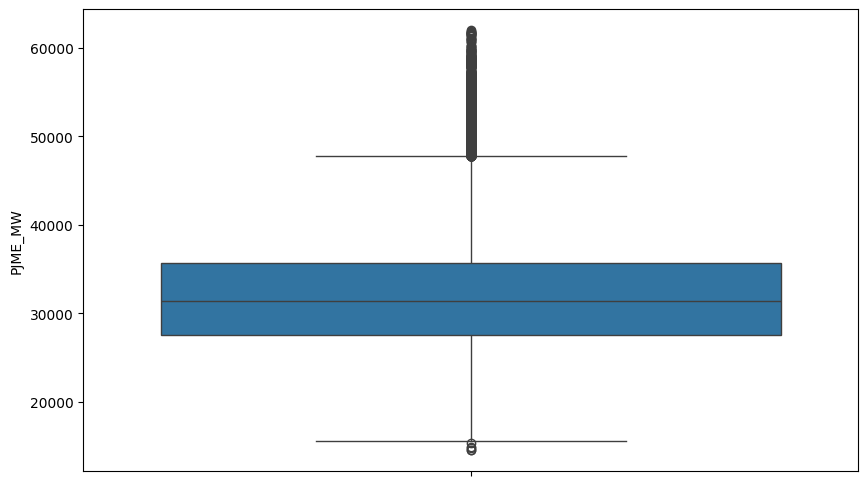

In [100]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df['PJME_MW'])

<Axes: title={'center': 'Histogram:'}, xlabel='PJME_MW', ylabel='Count'>

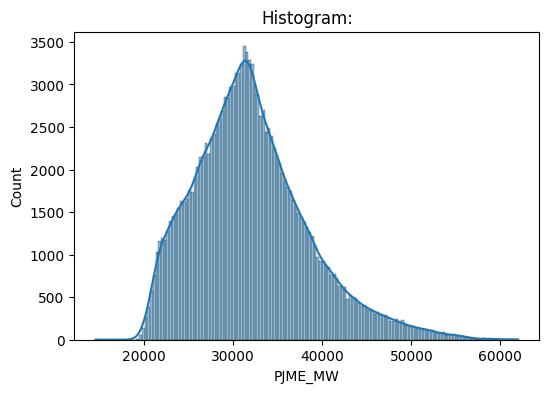

In [101]:
plt.figure(figsize=(6,4))
plt.title("Histogram:")
sns.histplot(df['PJME_MW'], kde=True)

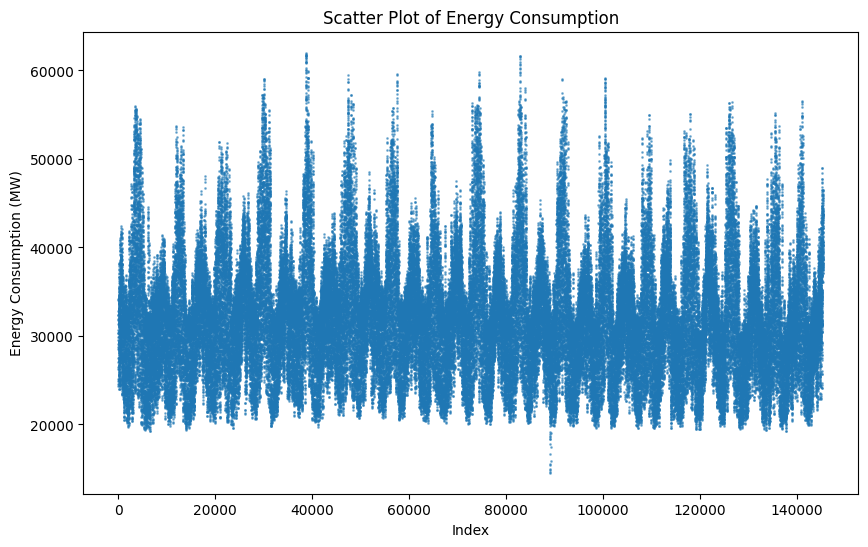

In [102]:
plt.figure(figsize=(10, 6))
plt.scatter(df.index, df['PJME_MW'], alpha=0.5, s=1)
plt.xlabel('Index')
plt.ylabel('Energy Consumption (MW)')
plt.title('Scatter Plot of Energy Consumption')
plt.show()

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)
print(f"Total numeric features: {len(numeric_cols)}")

Numeric columns: ['PJME_MW']
Total numeric features: 1


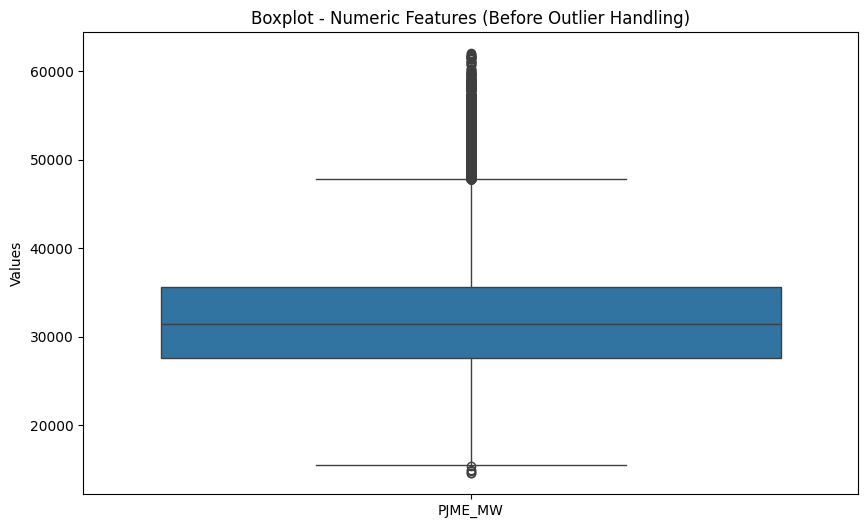

In [104]:
# i. Boxplot visualization for numeric features
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numeric_cols])
plt.title('Boxplot - Numeric Features (Before Outlier Handling)')
plt.ylabel('Values')
plt.show()

In [105]:
# ii. APPROACH 1: IQR Method (Interquartile Range)
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Detect outliers using IQR
col = 'PJME_MW'
outlier_count_iqr, lb, ub = detect_outliers_iqr(df, col)
print(" APPROACH 1: IQR Method")
print(f"Lower Bound: {lb:,.2f}")
print(f"Upper Bound: {ub:,.2f}")
print(f"Outliers detected: {outlier_count_iqr} ({outlier_count_iqr/len(df)*100:.2f}%)")

 APPROACH 1: IQR Method
Lower Bound: 15,457.50
Upper Bound: 47,765.50
Outliers detected: 3455 (2.38%)


In [106]:
# APPROACH 2: Z-Score Method
from scipy import stats

def detect_outliers_zscore(data, col, threshold=3):
    z_scores = np.abs(stats.zscore(data[col].dropna()))
    outliers = np.sum(z_scores > threshold)
    return outliers

outlier_count_zscore = detect_outliers_zscore(df, col)
print("📊 APPROACH 2: Z-Score Method (threshold=3)")
print(f"Outliers detected: {outlier_count_zscore} ({outlier_count_zscore/len(df)*100:.2f}%)")

📊 APPROACH 2: Z-Score Method (threshold=3)
Outliers detected: 1318 (0.91%)


In [107]:
# COMPARISON OF ALL APPROACHES
print("=" * 50)
print("COMPARISON OF OUTLIER DETECTION METHODS")
print("=" * 50)

comparison = pd.DataFrame({
    'Method': ['IQR (1.5×IQR)', 'Z-Score (>3)'],
    'Outliers Detected': [outlier_count_iqr, outlier_count_zscore],
    'Percentage': [f"{outlier_count_iqr/len(df)*100:.2f}%", 
                   f"{outlier_count_zscore/len(df)*100:.2f}%"]
})
print(comparison.to_string(index=False))

print("\n✅ RECOMMENDATION:")
print("• IQR Method: Best for skewed data, removes extreme outliers")
print("• Z-Score: Best for normally distributed data")

COMPARISON OF OUTLIER DETECTION METHODS
       Method  Outliers Detected Percentage
IQR (1.5×IQR)               3455      2.38%
 Z-Score (>3)               1318      0.91%

✅ RECOMMENDATION:
• IQR Method: Best for skewed data, removes extreme outliers
• Z-Score: Best for normally distributed data


In [108]:
# APPLY BEST METHOD: IQR (commonly used for energy data)
col = 'PJME_MW'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_clean = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)].copy()

print(f"Original dataset shape: {df.shape}")
print(f"After removing outliers: {df_clean.shape}")
print(f"Rows removed: {len(df) - len(df_clean)}")

Original dataset shape: (145366, 2)
After removing outliers: (141910, 2)
Rows removed: 3456


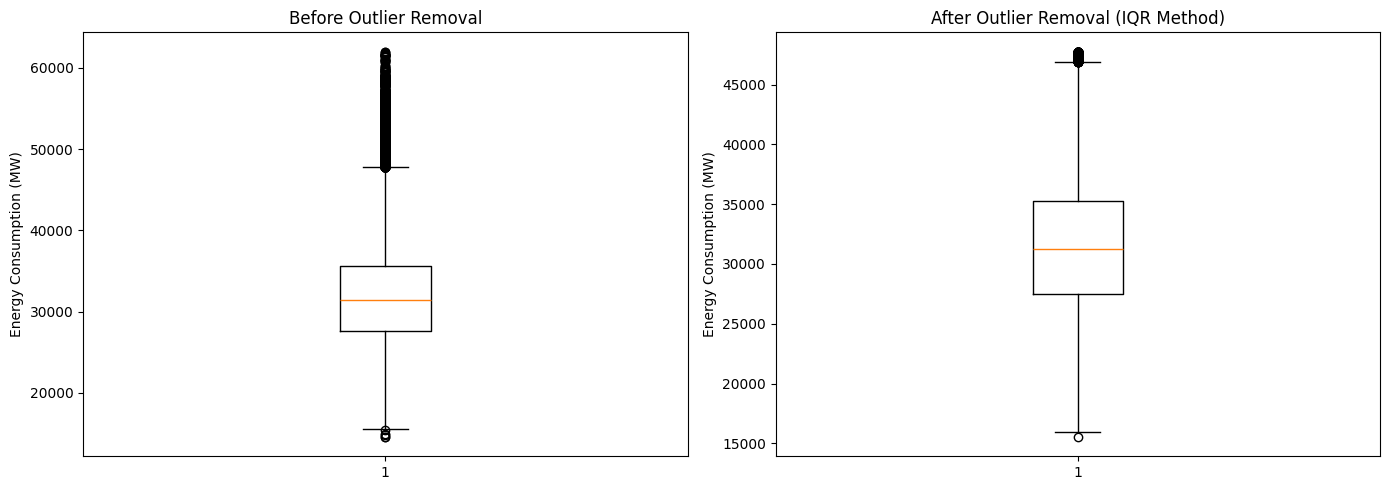

✅ Outlier handling complete using IQR method!


In [109]:
# BEFORE vs AFTER Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
axes[0].boxplot(df['PJME_MW'].dropna())
axes[0].set_title('Before Outlier Removal')
axes[0].set_ylabel('Energy Consumption (MW)')

# After
axes[1].boxplot(df_clean['PJME_MW'].dropna())
axes[1].set_title('After Outlier Removal (IQR Method)')
axes[1].set_ylabel('Energy Consumption (MW)')

plt.tight_layout()
plt.show()

print("✅ Outlier handling complete using IQR method!")

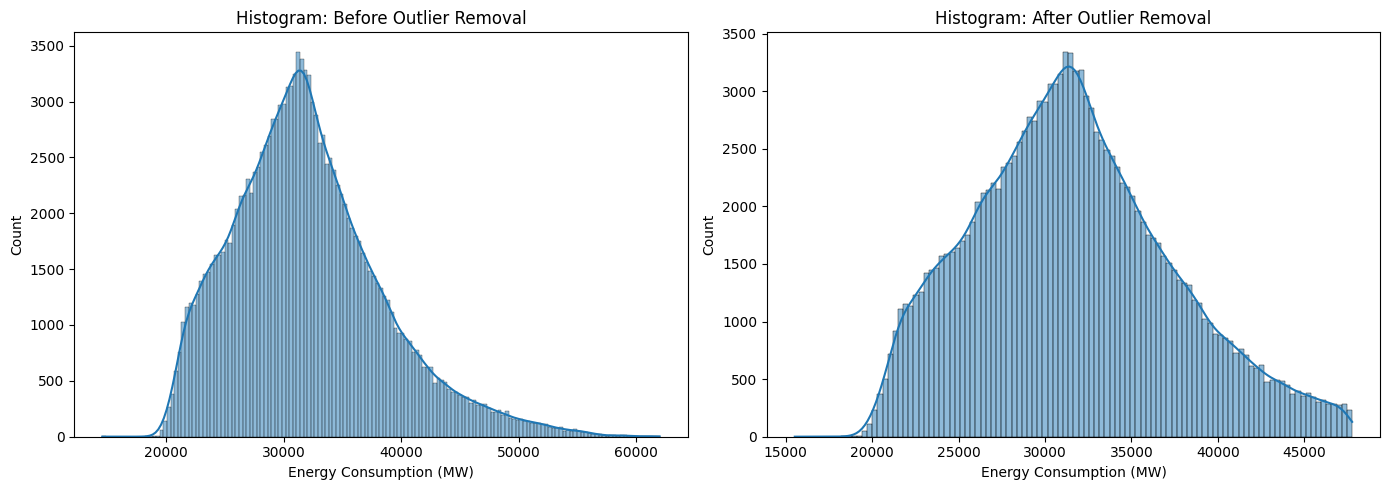

In [110]:
# Histogram - After Outlier Handling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
axes[0].set_title('Histogram: Before Outlier Removal')
sns.histplot(df['PJME_MW'], kde=True, ax=axes[0])
axes[0].set_xlabel('Energy Consumption (MW)')

# After
axes[1].set_title('Histogram: After Outlier Removal')
sns.histplot(df_clean['PJME_MW'], kde=True, ax=axes[1])
axes[1].set_xlabel('Energy Consumption (MW)')

plt.tight_layout()
plt.show()

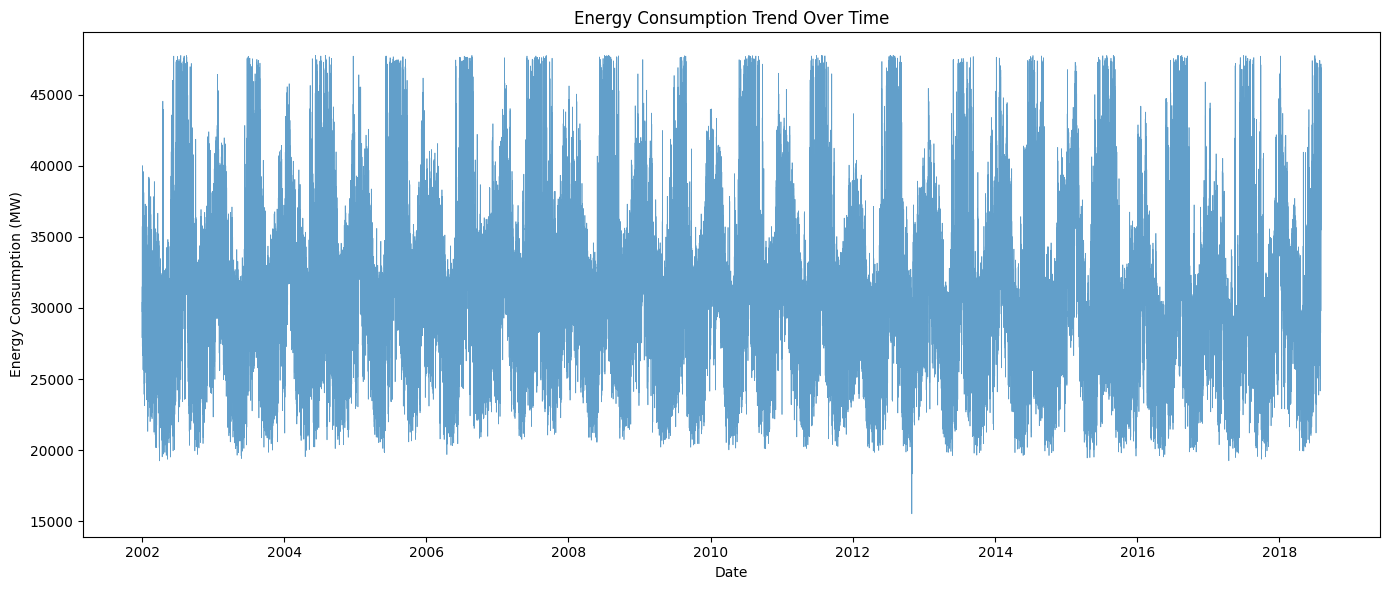

In [112]:
# Energy Consumption Trend Over Time

# Strip whitespace from column names (the CSV has " Datetime" with a leading space)
df_clean.columns = df_clean.columns.str.strip()

# Convert datetime column
df_clean['Datetime'] = pd.to_datetime(df_clean['Datetime'])
df_clean = df_clean.sort_values('Datetime')

plt.figure(figsize=(14, 6))
plt.plot(df_clean['Datetime'], df_clean['PJME_MW'], linewidth=0.5, alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Energy Consumption (MW)')
plt.title('Energy Consumption Trend Over Time')
plt.tight_layout()
plt.show()

In [113]:
# Identify Periods of High and Low Energy Usage

# Extract time features
df_clean['Hour'] = df_clean['Datetime'].dt.hour
df_clean['Month'] = df_clean['Datetime'].dt.month
df_clean['Year'] = df_clean['Datetime'].dt.year
df_clean['DayOfWeek'] = df_clean['Datetime'].dt.dayofweek  # 0=Monday, 6=Sunday

# Define high/low thresholds (using quartiles)
high_threshold = df_clean['PJME_MW'].quantile(0.75)
low_threshold = df_clean['PJME_MW'].quantile(0.25)

print(f"High usage threshold (Q3): {high_threshold:,.0f} MW")
print(f"Low usage threshold (Q1): {low_threshold:,.0f} MW")

High usage threshold (Q3): 35,248 MW
Low usage threshold (Q1): 27,461 MW


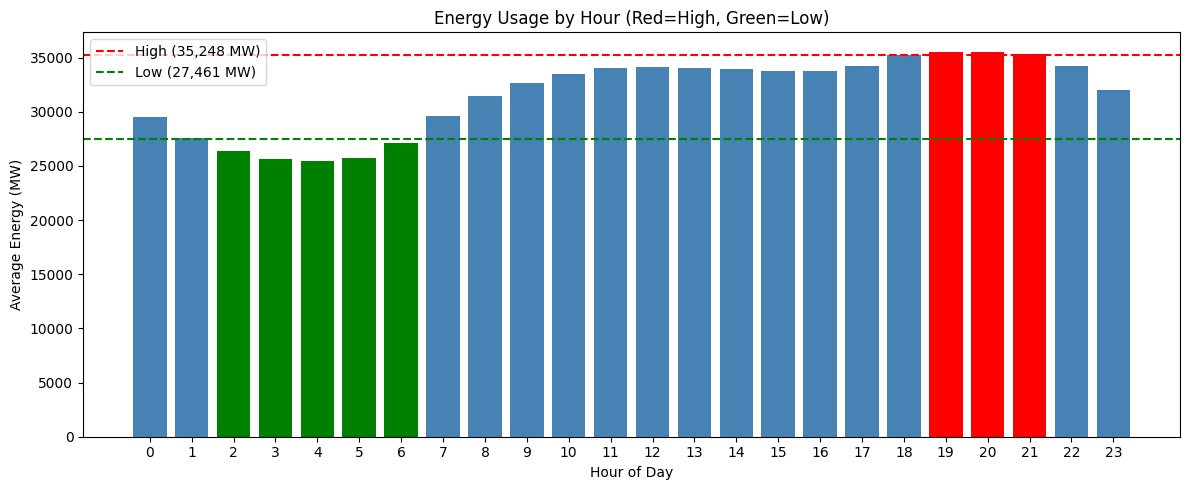


🔴 Peak Hours (Highest Usage): [19, 20, 21]
🟢 Off-Peak Hours (Lowest Usage): [4, 3, 5]


In [114]:
# Average Energy Usage by Hour
hourly_avg = df_clean.groupby('Hour')['PJME_MW'].mean()

plt.figure(figsize=(12, 5))
colors = ['red' if x >= high_threshold else 'green' if x <= low_threshold else 'steelblue' for x in hourly_avg]
plt.bar(hourly_avg.index, hourly_avg.values, color=colors)
plt.axhline(y=high_threshold, color='red', linestyle='--', label=f'High ({high_threshold:,.0f} MW)')
plt.axhline(y=low_threshold, color='green', linestyle='--', label=f'Low ({low_threshold:,.0f} MW)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy (MW)')
plt.title('Energy Usage by Hour (Red=High, Green=Low)')
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

print("\n🔴 Peak Hours (Highest Usage):", hourly_avg.nlargest(3).index.tolist())
print("🟢 Off-Peak Hours (Lowest Usage):", hourly_avg.nsmallest(3).index.tolist())

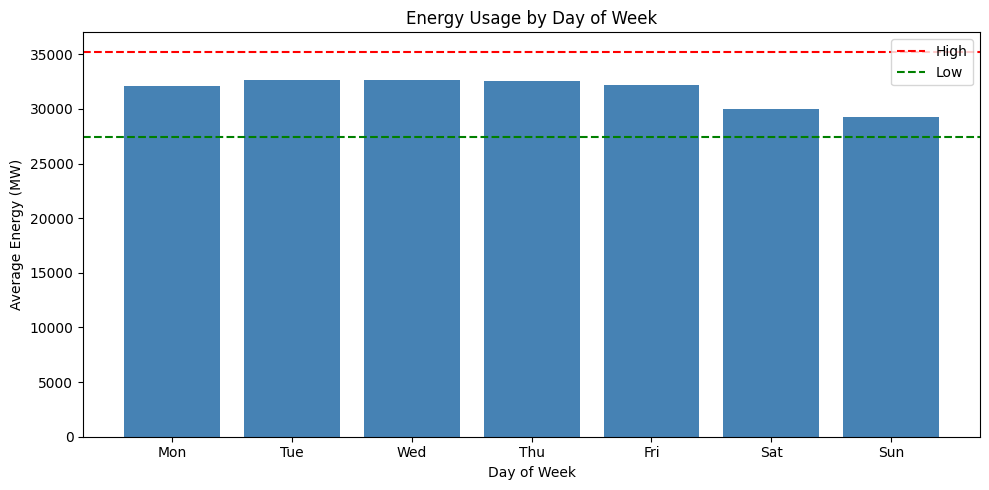


📅 Weekday vs Weekend:
Weekday Avg (Mon-Fri): 32,426 MW
Weekend Avg (Sat-Sun): 29,638 MW


In [115]:
# Average Energy Usage by Day of Week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_avg = df_clean.groupby('DayOfWeek')['PJME_MW'].mean()

plt.figure(figsize=(10, 5))
colors = ['red' if x >= high_threshold else 'green' if x <= low_threshold else 'steelblue' for x in daily_avg]
plt.bar(day_names, daily_avg.values, color=colors)
plt.axhline(y=high_threshold, color='red', linestyle='--', label='High')
plt.axhline(y=low_threshold, color='green', linestyle='--', label='Low')
plt.xlabel('Day of Week')
plt.ylabel('Average Energy (MW)')
plt.title('Energy Usage by Day of Week')
plt.legend()
plt.tight_layout()
plt.show()

print("\n📅 Weekday vs Weekend:")
print(f"Weekday Avg (Mon-Fri): {daily_avg[:5].mean():,.0f} MW")
print(f"Weekend Avg (Sat-Sun): {daily_avg[5:].mean():,.0f} MW")

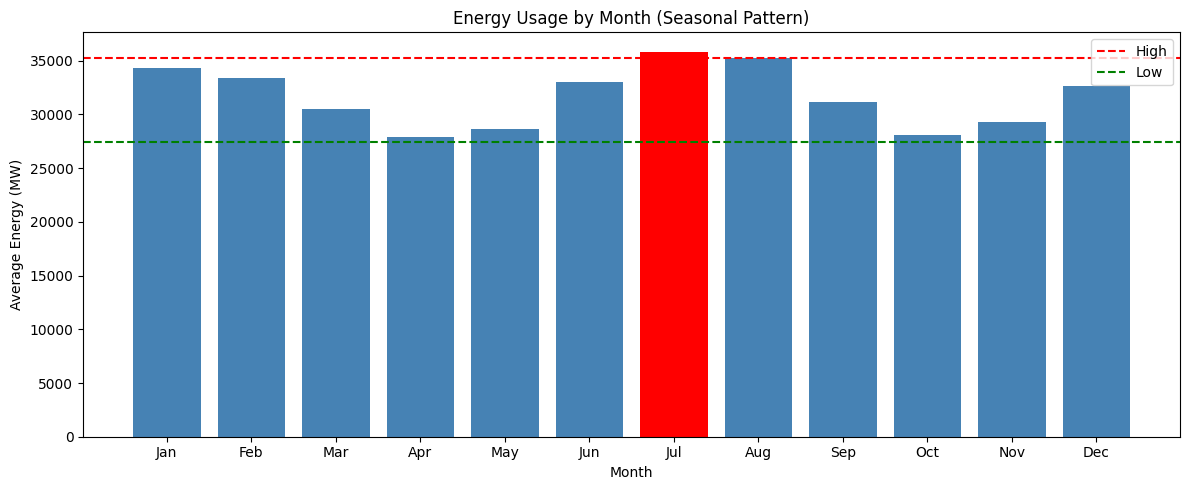


🌡️ Seasonal Analysis:
🔴 Highest months: [7, 8, 1] (Summer/Winter peaks)
🟢 Lowest months: [4, 10, 5] (Spring/Fall)


In [116]:
# Average Energy Usage by Month (Seasonal Pattern)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_avg = df_clean.groupby('Month')['PJME_MW'].mean()

plt.figure(figsize=(12, 5))
colors = ['red' if x >= high_threshold else 'green' if x <= low_threshold else 'steelblue' for x in monthly_avg]
plt.bar(month_names, monthly_avg.values, color=colors)
plt.axhline(y=high_threshold, color='red', linestyle='--', label='High')
plt.axhline(y=low_threshold, color='green', linestyle='--', label='Low')
plt.xlabel('Month')
plt.ylabel('Average Energy (MW)')
plt.title('Energy Usage by Month (Seasonal Pattern)')
plt.legend()
plt.tight_layout()
plt.show()

print("\n🌡️ Seasonal Analysis:")
print(f"🔴 Highest months: {monthly_avg.nlargest(3).index.tolist()} (Summer/Winter peaks)")
print(f"🟢 Lowest months: {monthly_avg.nsmallest(3).index.tolist()} (Spring/Fall)")

In [117]:
# Summary: Top 10 Highest and Lowest Usage Periods
print("=" * 60)
print("📊 SUMMARY: HIGH vs LOW ENERGY USAGE PERIODS")
print("=" * 60)

# Top 10 highest
print("\n🔴 TOP 10 HIGHEST USAGE PERIODS:")
top_high = df_clean.nlargest(10, 'PJME_MW')[['Datetime', 'PJME_MW']]
print(top_high.to_string(index=False))

# Top 10 lowest
print("\n🟢 TOP 10 LOWEST USAGE PERIODS:")
top_low = df_clean.nsmallest(10, 'PJME_MW')[['Datetime', 'PJME_MW']]
print(top_low.to_string(index=False))

📊 SUMMARY: HIGH vs LOW ENERGY USAGE PERIODS

🔴 TOP 10 HIGHEST USAGE PERIODS:
           Datetime  PJME_MW
2012-07-26 14:00:00  47765.0
2004-07-30 14:00:00  47763.0
2008-07-23 15:00:00  47763.0
2016-07-29 16:00:00  47763.0
2015-08-31 15:00:00  47762.0
2004-06-09 13:00:00  47760.0
2006-08-22 18:00:00  47756.0
2010-07-15 21:00:00  47756.0
2016-08-17 13:00:00  47755.0
2011-07-24 21:00:00  47754.0

🟢 TOP 10 LOWEST USAGE PERIODS:
           Datetime  PJME_MW
2012-10-30 06:00:00  15526.0
2012-10-30 00:00:00  15919.0
2012-10-30 07:00:00  16688.0
2012-10-29 23:00:00  17422.0
2012-10-30 08:00:00  17734.0
2012-10-31 04:00:00  18330.0
2012-10-31 03:00:00  18350.0
2012-10-31 02:00:00  18618.0
2012-10-30 09:00:00  18675.0
2012-10-31 05:00:00  18880.0


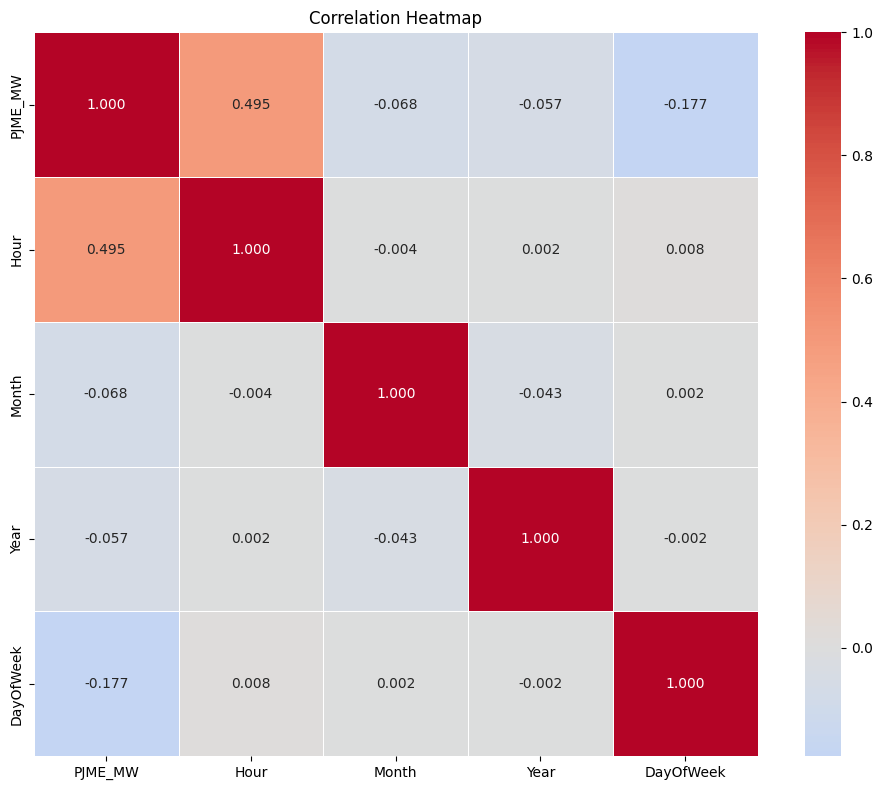


📊 Correlation with Energy Consumption (PJME_MW):
Hour         0.494669
Year        -0.057241
Month       -0.068018
DayOfWeek   -0.176561
Name: PJME_MW, dtype: float64


In [118]:
# Correlation Analysis
# Select numeric columns for correlation
numeric_features = ['PJME_MW', 'Hour', 'Month', 'Year', 'DayOfWeek']
correlation_matrix = df_clean[numeric_features].corr()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Print correlation with target
print("\n📊 Correlation with Energy Consumption (PJME_MW):")
corr_with_target = correlation_matrix['PJME_MW'].drop('PJME_MW').sort_values(ascending=False)
print(corr_with_target)